In [249]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Import du dataset

In [250]:
df = pd.read_csv(
    "../data/eco2mix-national-cons-def.csv",
    sep=";",
    encoding="utf-8-sig",
    index_col=False
)

df = df.sort_values(by=["Date", "Heure"], ascending=True).reset_index(drop=True)

C:\Users\trist\AppData\Local\Temp\ipykernel_28464\2261834993.py:1: DtypeWarning: Columns (0: Ech. comm. Allemagne-Belgique (MW), 1: Gaz - Cogénération (MW)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## Datacard

In [251]:
from datetime import datetime
import yaml

In [ ]:
n = len(df)

datacard = {
    "name": "eCO2mix_RTE_Annuel-Definitif",
    "version": "1.0",
    "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "domain": "energy",
    "period": "2012-2026",
    "data": {
        "instance_count": n,
        "feature_count": df.shape[1],
        "feature_list": {},
    }
}

description = {
    "Périmètre": "France",
    "Nature": "Données temps réel / Données consolidées / Données définitives",
    "Date": "Date du jour (jj/mm/aaaa)",
    "Heures": "Point horaire par pas de 15 minutes (hh:mm)",
    "Consommation": "Consommation en MW",
    "Prévision J-1": "Prévision J-1 de consommation en MW",
    "Prévision J": "Prévision J de consommation en MW",
    "Fioul": "Production fioul en MW",
    "Charbon": "Production charbon en MW",
    "Gaz": "Production gaz en MW",
    "Nucléaire": "Production nucléaire en MW",
    "Eolien": "Production éolienne en MW",
    "Solaire": "Production solaire en MW",
    "Hydraulique": "Production hydraulique en MW",
    "Pompage": "Pompage hydraulique en MW",
    "Bioénergies": "Production Bioénergies en MW",
    "Ech. physiques": "Solde imports/exports (flux physiques) en MW",
    "Taux de CO2": "Estimation des émissions de CO2 en g/kWh",
    "Ech. comm. Angleterre": "Solde imports/exports Angleterre (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Espagne": "Solde imports/exports Espagne (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Italie": "Solde imports/exports Italie (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Suisse": "Solde imports/exports Suisse (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Allemagne-Belgique": "Solde imports/exports Allemagne-Belgique (programmes d'échanges commerciaux) en MW",
    "Fioul - TAC": "Détail technologie turbine à combustion pour la filière fioul",
    "Fioul - Cogén.": "Détail technologie cogénération pour la filière fioul",
    "Fioul - Autres": "Détail autres technologies pour la filière fioul",
    "Gaz - TAC": "Détail technologie turbine à combustion pour la filière gaz",
    "Gaz - Cogén.": "Détail technologie cogénération pour la filière gaz",
    "Gaz - CCG": "Détail technologie cycle combiné gaz pour la filière gaz",
    "Gaz - Autres": "Détail autres technologies pour la filière gaz",
    "Hydraulique - Fil de l'eau + éclusée": "Détail technologie fil de l'eau et éclusée pour la filière hydraulique",
    "Hydraulique - Lacs": "Détail technologie lacs pour la filière hydraulique",
    "Hydraulique - STEP turbinage": "Détail technologie STEP turbinage pour la filière hydraulique",
    "Bioénergies - Déchets": "Détail technologie déchets pour la filière Bioénergies",
    "Bioénergies - Biomasse": "Détail technologie biomasse pour la filière Bioénergies",
    "Bioénergies - Biogaz": "Détail technologie biogaz pour la filière Bioénergies",
    "Stockage batterie": "Détail soutirage batteries",
    "Déstockage batterie": "Détail injections batteries",
    "Eolien terrestre": "Détail technologie éolien terrestre pour la filière Eolien",
    "Eolien offshore": "Détail technologie éolien en mer pour la filière Eolien",
}

count = df.count()
nunique = df.nunique()
missing = df.isna().sum()

df_stats = pd.DataFrame({
    "count": count.astype(int),
    "unique_count": nunique.astype(int),
    "duplicate_count": (count - nunique).astype(int),
    "duplicate_ratio": ((count - nunique) / count).round(2).astype(float),
    "missing_count": missing.astype(int),
    "missing_ratio": (missing / n).round(2).astype(float),
})
describe = df.describe().astype(float)

for idx, row in df_stats.iterrows():
    card = {
        "description": description.get(idx, ""),
        "type": str(df[idx].dtypes),
        "stats": row.to_dict(),
        "sample": df[idx].dropna().unique()[:5].tolist()
    }

    if pd.api.types.is_numeric_dtype(df[idx]):
        card.update({
            'stats': {
                **row.to_dict(),
                **describe[idx].to_dict()
            }
        })

    datacard["data"]["feature_list"][idx] = card

In [253]:
with open("../data/raw_data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(datacard, f, sort_keys=False, allow_unicode=True)

## Exploration

In [254]:
df.head(10)

,Périmètre,Nature,Date,Heure,Date et Heure,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),...,Gaz - TAC (MW),Gaz - Cogénération (MW),Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW)
0,France,Données définitives,2012-01-01,00:00,2012-01-01T00:00:00+01:00,58315.0,58200,58200,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,France,Données définitives,2012-01-01,00:15,2012-01-01T00:15:00+01:00,NaN,57700,57550,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,2012-01-01T00:30:00+01:00,58315.0,57200,56900,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,France,Données définitives,2012-01-01,00:45,2012-01-01T00:45:00+01:00,NaN,56200,56000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2012-01-01,01:00,2012-01-01T01:00:00+01:00,56231.0,55200,55100,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,France,Données définitives,2012-01-01,01:15,2012-01-01T01:15:00+01:00,NaN,55600,55250,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,France,Données définitives,2012-01-01,01:30,2012-01-01T01:30:00+01:00,56075.0,56000,55400,491.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,France,Données définitives,2012-01-01,01:45,2012-01-01T01:45:00+01:00,NaN,56000,55200,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,France,Données définitives,2012-01-01,02:00,2012-01-01T02:00:00+01:00,55532.0,56000,55000,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,France,Données définitives,2012-01-01,02:15,2012-01-01T02:15:00+01:00,NaN,55750,54300,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [255]:
# On retire les données au pas 00:15 et 00:45 car les données définitives fonctionnent par pas de 30 minutes
df = df.dropna(subset=["Consommation (MW)"])

# On corrige les types des colonnes d'échanges pour pouvoir les travailler
cols_ech = ["Ech. comm. Angleterre (MW)", "Ech. comm. Italie (MW)", "Ech. comm. Espagne (MW)", "Ech. comm. Suisse (MW)", "Ech. comm. Allemagne-Belgique (MW)"]
df[cols_ech] = df[cols_ech].apply(pd.to_numeric, errors='coerce')

In [256]:
df.head(10)

,Périmètre,Nature,Date,Heure,Date et Heure,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),...,Gaz - TAC (MW),Gaz - Cogénération (MW),Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW)
0,France,Données définitives,2012-01-01,00:00,2012-01-01T00:00:00+01:00,58315.0,58200,58200,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,2012-01-01T00:30:00+01:00,58315.0,57200,56900,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2012-01-01,01:00,2012-01-01T01:00:00+01:00,56231.0,55200,55100,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,France,Données définitives,2012-01-01,01:30,2012-01-01T01:30:00+01:00,56075.0,56000,55400,491.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,France,Données définitives,2012-01-01,02:00,2012-01-01T02:00:00+01:00,55532.0,56000,55000,492.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,France,Données définitives,2012-01-01,02:30,2012-01-01T02:30:00+01:00,54911.0,55500,53600,492.0,26.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,France,Données définitives,2012-01-01,03:00,2012-01-01T03:00:00+01:00,52496.0,52400,51100,494.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,France,Données définitives,2012-01-01,03:30,2012-01-01T03:30:00+01:00,50664.0,50800,49200,491.0,24.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,France,Données définitives,2012-01-01,04:00,2012-01-01T04:00:00+01:00,49161.0,49100,47600,492.0,24.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,France,Données définitives,2012-01-01,04:30,2012-01-01T04:30:00+01:00,47596.0,47800,46400,492.0,24.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [257]:
df.describe()

,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),Gaz (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),...,Fioul - Autres (MW),Gaz - TAC (MW),Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW)
count,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,246960.000000,...,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000,229391.000000
mean,53084.492347,52611.988277,52542.107451,235.592687,720.638306,3252.355637,42456.792898,3600.369695,1513.654280,7154.895181,...,73.689003,44.850897,1963.638294,231.553252,4627.230319,1848.420413,674.725595,486.531856,298.790733,277.485547
std,11780.297564,11781.620943,11750.324701,266.612984,1048.512664,2467.530793,7735.669773,3249.308564,2674.203452,2824.596832,...,167.998415,93.895940,1806.755436,383.805309,1525.688273,1142.891634,771.147460,59.194505,87.323709,64.764574
min,29124.000000,27500.000000,0.000000,18.000000,-133.000000,196.000000,19164.000000,21.000000,-23.000000,1387.000000,...,-13.000000,-10.000000,-18.000000,3.000000,1209.000000,46.000000,-2.000000,229.000000,111.000000,111.000000
25%,44182.000000,43700.000000,43700.000000,84.000000,15.000000,933.000000,37844.000000,1314.000000,0.000000,5001.000000,...,5.000000,0.000000,226.000000,49.000000,3356.000000,982.000000,11.000000,449.000000,246.000000,219.000000
50%,51290.500000,50800.000000,50800.000000,134.000000,59.000000,2754.000000,41997.000000,2511.000000,22.000000,6910.000000,...,18.000000,5.000000,1372.000000,71.000000,4745.000000,1632.000000,379.000000,491.000000,296.000000,300.000000
75%,60981.000000,60500.000000,60300.000000,315.000000,1104.000000,4851.000000,47501.000000,4809.000000,2044.000000,9019.250000,...,44.000000,41.000000,3515.000000,117.000000,5854.000000,2472.000000,1083.000000,529.000000,355.000000,334.000000
max,102098.000000,101000.000000,102700.000000,5926.000000,6265.000000,10611.000000,61712.000000,20131.000000,21627.000000,17947.000000,...,3576.000000,790.000000,6580.000000,2530.000000,8430.000000,7211.000000,4293.000000,2655.000000,661.000000,448.000000


In [258]:
df.columns

Index(['Périmètre', 'Nature', 'Date', 'Heure', 'Date et Heure',
       'Consommation (MW)', 'Prévision J-1 (MW)', 'Prévision J (MW)',
       'Fioul (MW)', 'Charbon (MW)', 'Gaz (MW)', 'Nucléaire (MW)',
       'Eolien (MW)', 'Solaire (MW)', 'Hydraulique (MW)', 'Pompage (MW)',
       'Bioénergies (MW)', 'Ech. physiques (MW)', 'Taux de CO2 (g/kWh)',
       'Ech. comm. Angleterre (MW)', 'Ech. comm. Espagne (MW)',
       'Ech. comm. Italie (MW)', 'Ech. comm. Suisse (MW)',
       'Ech. comm. Allemagne-Belgique (MW)', 'Fioul - TAC (MW)',
       'Fioul - Cogénération (MW)', 'Fioul - Autres (MW)', 'Gaz - TAC (MW)',
       'Gaz - Cogénération (MW)', 'Gaz - CCG (MW)', 'Gaz - Autres (MW)',
       'Hydraulique - Fil de l'eau + éclusée (MW)', 'Hydraulique - Lacs (MW)',
       'Hydraulique - STEP turbinage (MW)', 'Bioénergies - Déchets (MW)',
       'Bioénergies - Biomasse (MW)', 'Bioénergies - Biogaz (MW)'],
      dtype='str')

In [259]:
# Les colonnes qui ne contiennent qu'une seule même valeur pour toutes ses observations
df.columns[df.nunique() == 1]

Index(['Périmètre'], dtype='str')

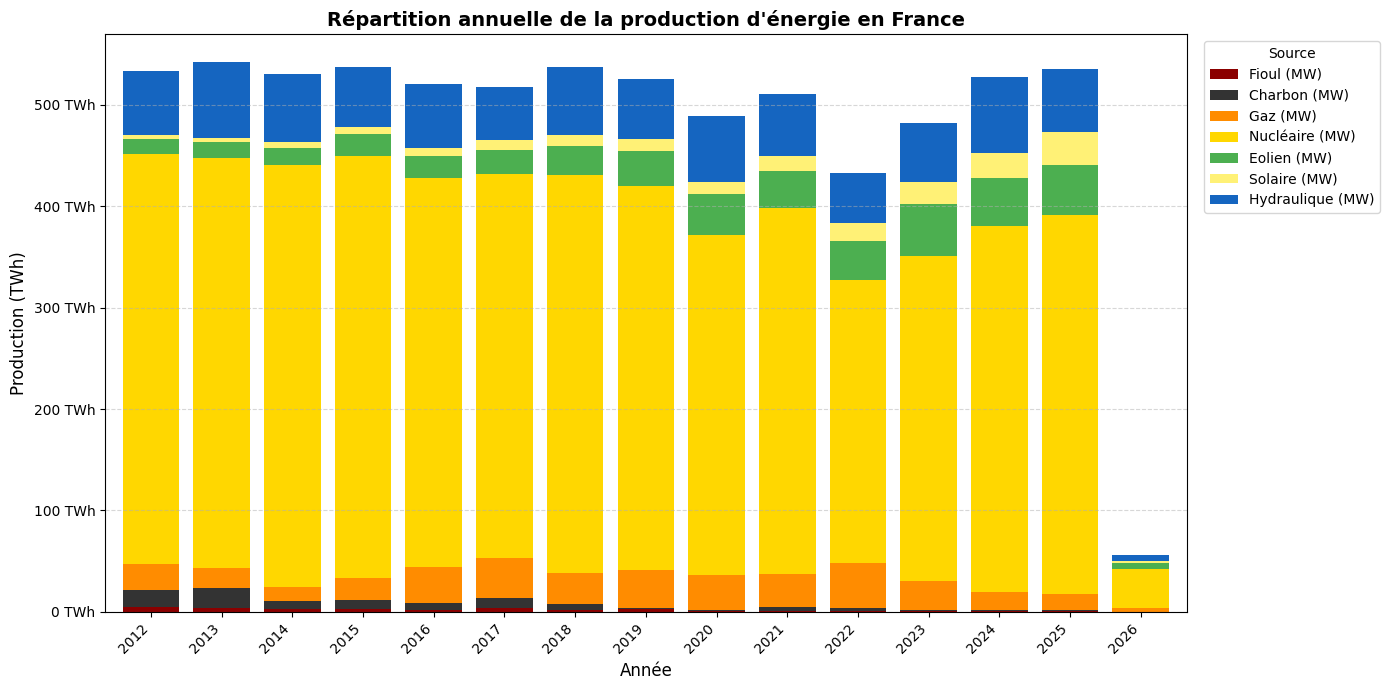

In [260]:
df["Date"] = pd.to_datetime(df["Date"])
df["Année"] = df["Date"].dt.to_period("Y")

energy_cols = ["Fioul (MW)", "Charbon (MW)", "Gaz (MW)", "Nucléaire (MW)", "Eolien (MW)", "Solaire (MW)", "Hydraulique (MW)"]

annually = df.groupby("Année")[energy_cols].sum() * 0.5 # 0.5 pour remettre en heure car nous avons des relevés toutes les 30 minutes

# Convertir en TWh pour lisibilité
annually_twh = annually / 1e6

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#8B0000", "#333333", "#FF8C00", "#FFD700", "#4CAF50", "#FFF176", "#1565C0"]

annually_twh.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Répartition annuelle de la production d'énergie en France", fontsize=14, fontweight="bold")
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Production (TWh)", fontsize=12)
ax.set_xticklabels([str(m) for m in annually_twh.index], rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} TWh"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

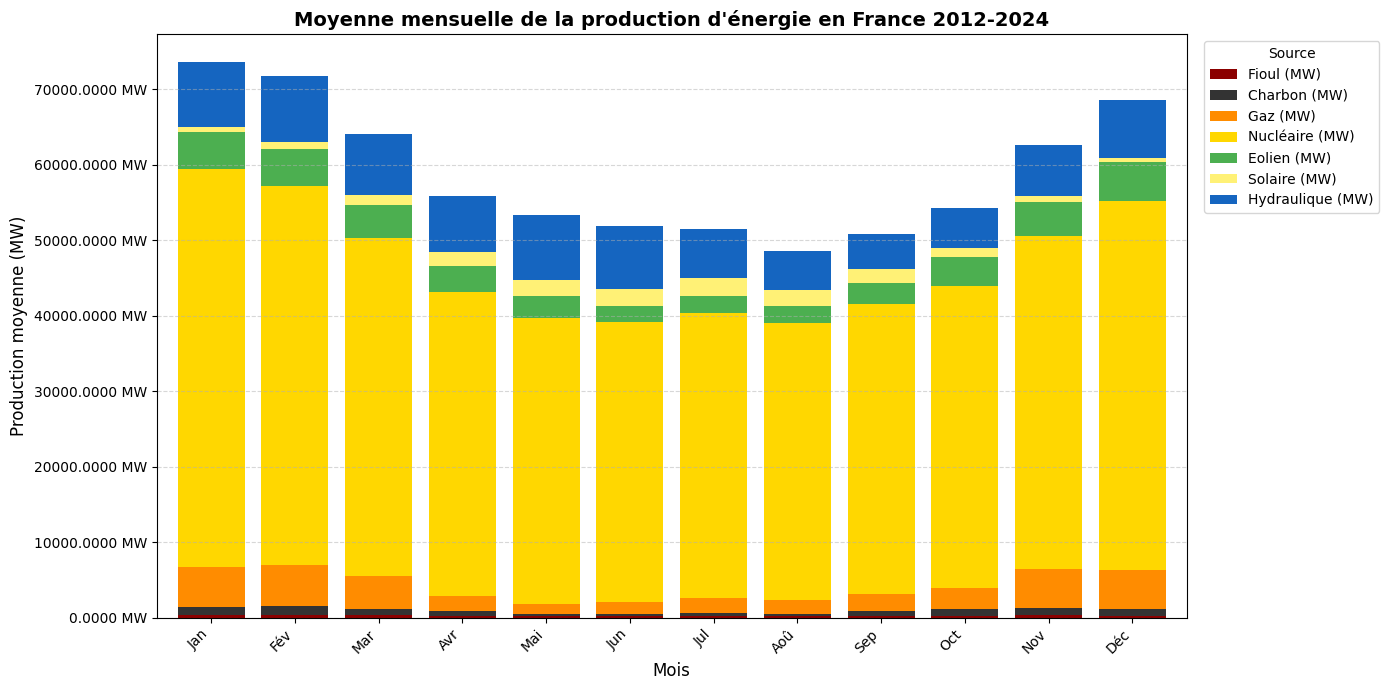

In [261]:
df["Mois"] = df["Date"].dt.month

monthly_avg = df.groupby("Mois")[energy_cols].mean()

month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(14, 7))

monthly_avg.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Moyenne mensuelle de la production d'énergie en France 2012-2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Production moyenne (MW)", fontsize=12)
ax.set_xticklabels(month_labels, rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.4f} MW"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [262]:
energy_cols = ["Fioul (MW)", "Charbon (MW)", "Gaz (MW)", "Nucléaire (MW)", "Eolien (MW)", "Solaire (MW)", "Hydraulique (MW)", "Bioénergies (MW)"]

colors = [
    '#E63946',
    '#2196F3',
    '#2A9D8F',
    '#F4A261',
    '#8338EC',
    '#FFBE0B',
    '#FB5607',
    '#3A86FF',
    '#06D6A0',
    '#FF006E',
]

df["Production (MW)"] = df[energy_cols].sum(axis=1)

def add_column(groupby, label, color):
    ax.fill_between(range(len(groupby)), 0, groupby[label], alpha=0.1, color=color)
    ax.plot(groupby[label], color=color, label=label)

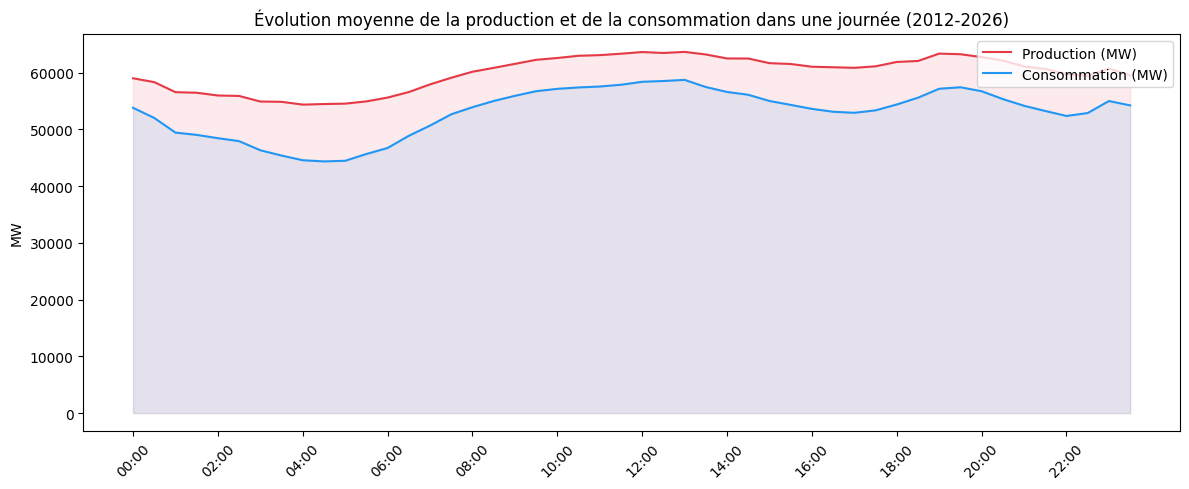

In [263]:
df["Heure"] = pd.Categorical(df["Heure"], categories=sorted(df["Heure"].unique()), ordered=True)

hourly_avg = df.groupby("Heure")[["Consommation (MW)", "Production (MW)"]].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

add_column(hourly_avg, "Production (MW)", colors[0])
add_column(hourly_avg, "Consommation (MW)", colors[1])

ax.set_xticks(range(0, 48, 4))
ax.set_xticklabels(hourly_avg.index[::4], rotation=45)
ax.set_ylabel("MW")
ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
plt.title("Évolution moyenne de la production et de la consommation dans une journée (2012-2026)")
plt.tight_layout()
plt.show()

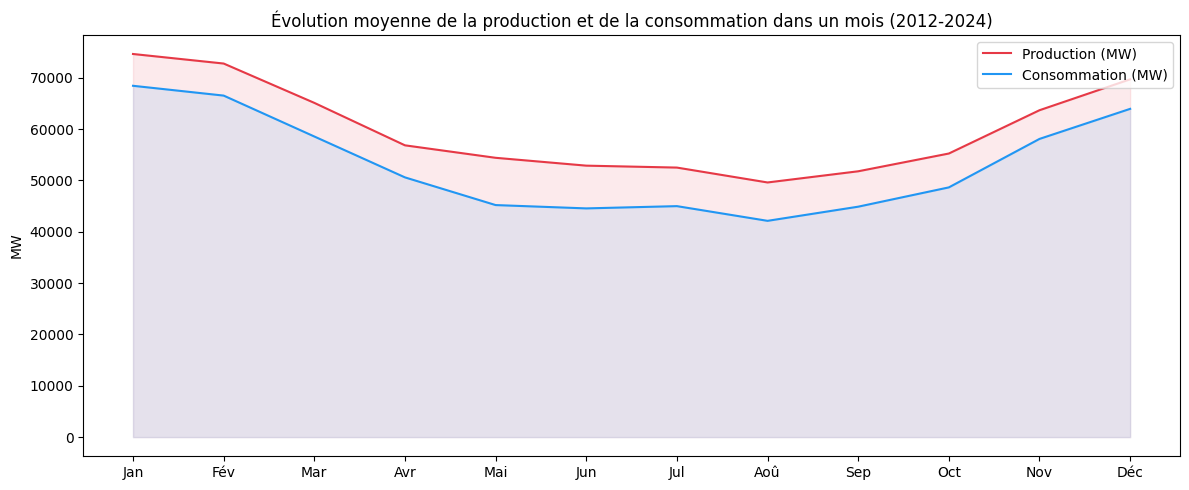

In [264]:
month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

monthly_avg = df.groupby("Mois")[["Consommation (MW)", "Production (MW)"]].mean().sort_index()
monthly_avg.index = month_labels

fig, ax = plt.subplots(figsize=(12, 5))

add_column(monthly_avg, "Production (MW)", colors[0])
add_column(monthly_avg, "Consommation (MW)", colors[1])

ax.set_ylabel("MW")
ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
plt.title("Évolution moyenne de la production et de la consommation dans un mois (2012-2024)")
plt.tight_layout()
plt.show()

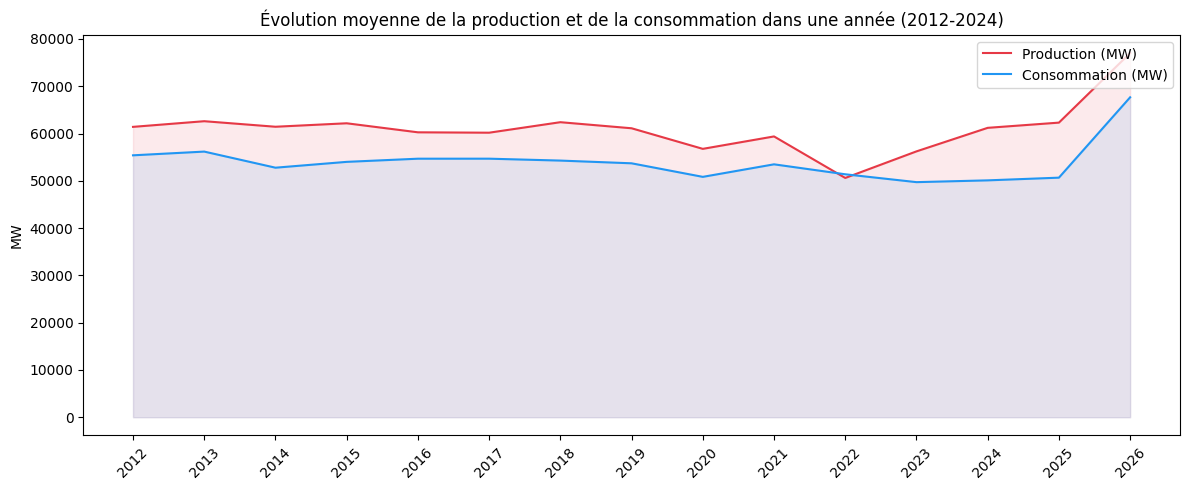

In [265]:
yearly_avg = df.groupby("Année")[["Consommation (MW)", "Production (MW)"]].mean().reset_index()
year_labels = sorted(df["Année"].unique())

fig, ax = plt.subplots(figsize=(12, 5))

add_column(yearly_avg, "Production (MW)", colors[0])
add_column(yearly_avg, "Consommation (MW)", colors[1])

ax.set_xticks(range(len(year_labels)), year_labels, rotation=45)
ax.set_ylabel("MW")
ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
plt.title("Évolution moyenne de la production et de la consommation dans une année (2012-2024)")
plt.tight_layout()
plt.show()

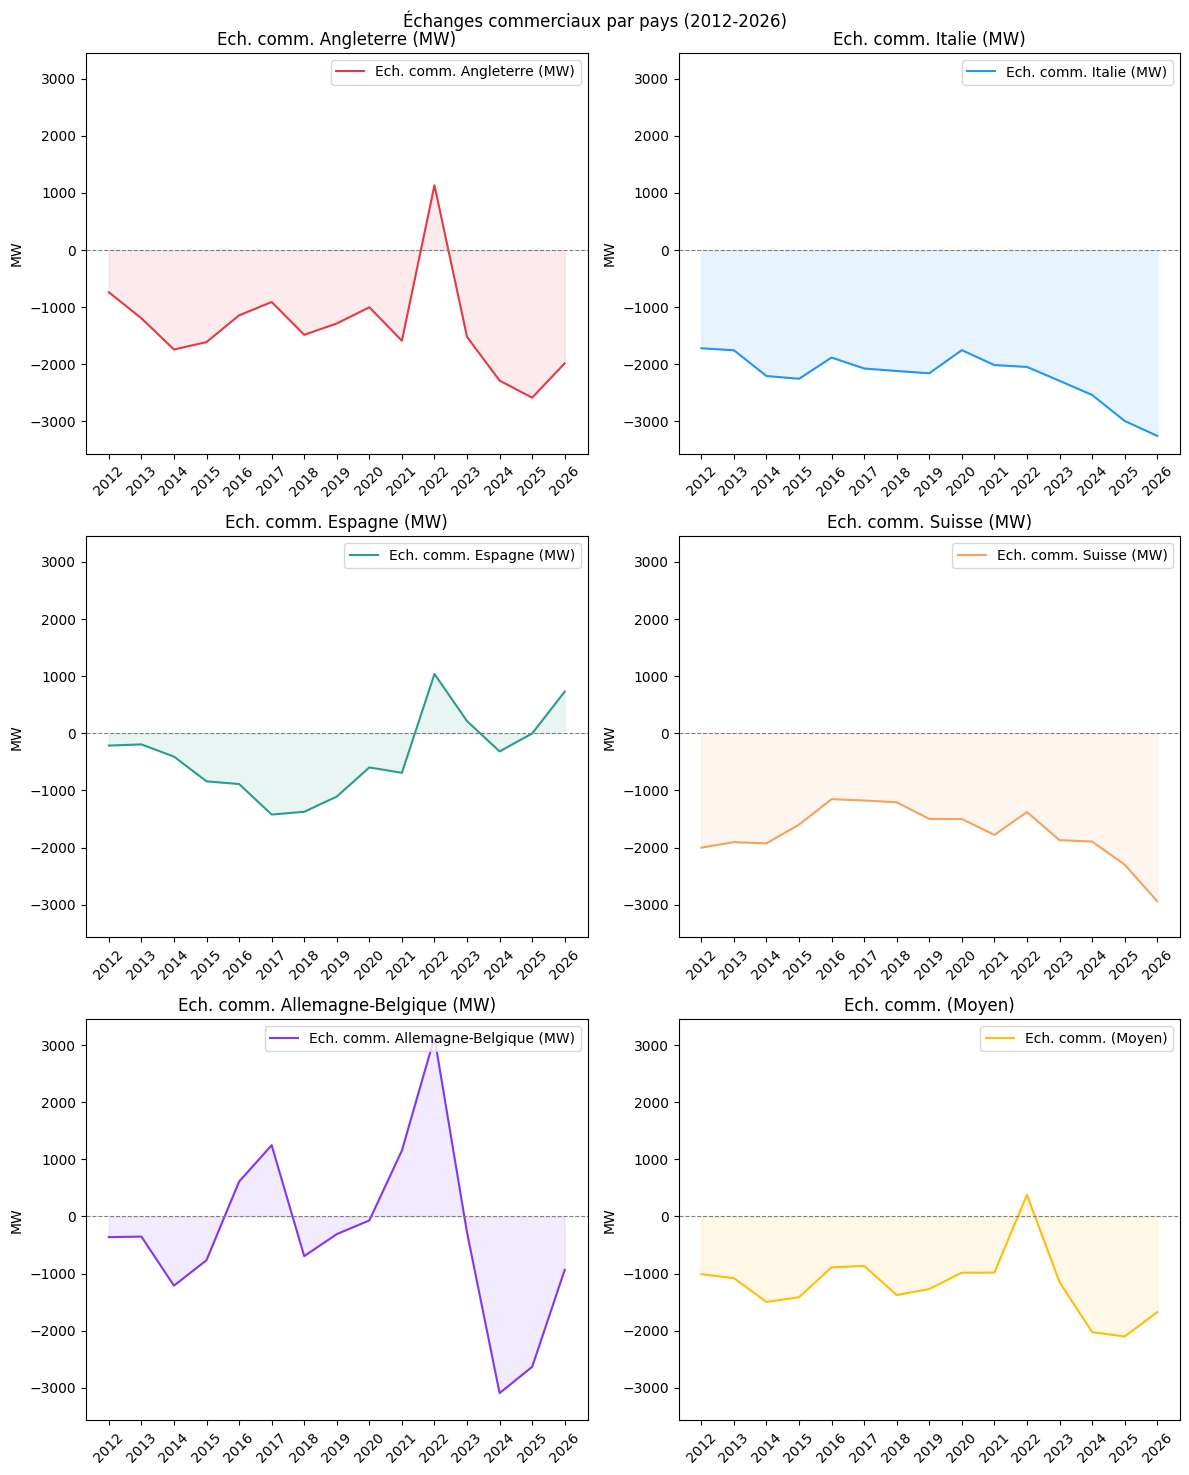

In [266]:
df["Ech. comm. (Moyen)"] = df[cols_ech].mean(axis=1)

cols_ech = ["Ech. comm. Angleterre (MW)", "Ech. comm. Italie (MW)", "Ech. comm. Espagne (MW)", "Ech. comm. Suisse (MW)", "Ech. comm. Allemagne-Belgique (MW)", "Ech. comm. (Moyen)"]

exchange_avg = df.groupby("Année")[cols_ech].mean().reset_index()
year_labels = sorted(df["Année"].unique())

fig, axes = plt.subplots(3, 2, figsize=(12, 15), sharey=True)

for ax, (col, color) in zip(axes.flatten(), zip(cols_ech, colors)):
    add_column(exchange_avg, col, color)
    ax.legend(loc="upper right",  bbox_to_anchor=(1, 1))
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(col)
    ax.set_xticks(range(len(year_labels)), year_labels, rotation=45)
    ax.set_ylabel("MW")
    ax.tick_params(labelleft=True)

plt.suptitle("Échanges commerciaux par pays (2012-2026)")
plt.tight_layout()

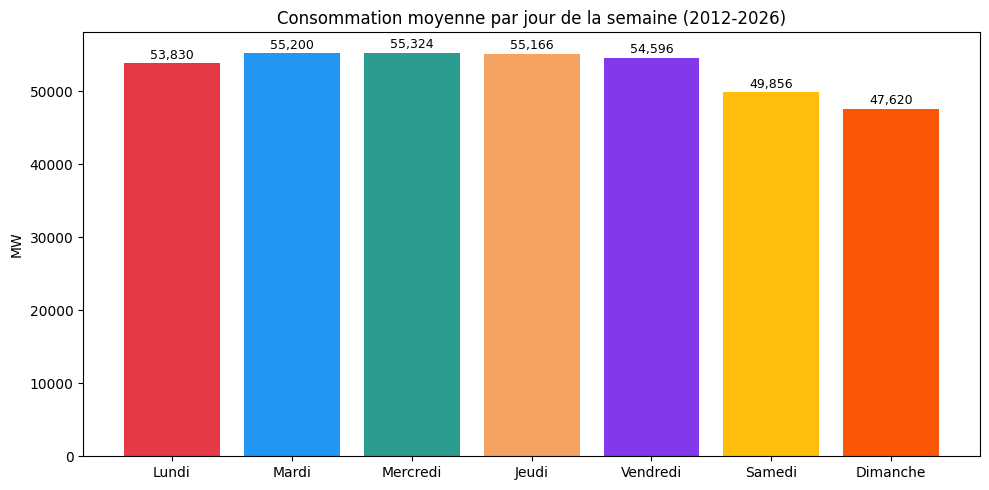

In [267]:
df["Jour"] = df["Date"].dt.dayofweek

jour_labels = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

daily_avg = df.groupby("Jour")["Consommation (MW)"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(daily_avg["Jour"], daily_avg["Consommation (MW)"], color=colors[:7])
ax.set_xticks(range(7), jour_labels)
ax.set_ylabel("MW")
ax.set_title("Consommation moyenne par jour de la semaine (2012-2026)")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()